# 🪐 Program Kurva Elips
> **Parametric Generation of Conic Curves**
> *Visualisasi dan Analisis Pengaruh Nilai $\Delta\theta$ terhadap Resolusi Kurva*

---

## 📌 Deskripsi
Program ini digunakan untuk membangkitkan **kurva elips** menggunakan persamaan parametrik. Selain itu, program ini dirancang untuk membandingkan secara visual dan matematis pengaruh interval **$\Delta\theta$ (delta theta)** terhadap jumlah titik pembentuk dan kualitas *smoothness* (kehalusan) visualisasi kurva.

## 🎯 Tujuan Simulasi
1. Mengimplementasikan persamaan parametrik trigonometri untuk membentuk kurva elips.
2. Menampilkan tabulasi titik-titik koordinat $(x, y)$ pembentuk kurva.
3. Menganalisis perbandingan resolusi grafis berdasarkan variasi nilai $\Delta\theta$.
4. Membuktikan secara komputasional bahwa semakin kecil nilai $\Delta\theta$, maka kerapatan titik semakin tinggi sehingga kurva terbentuk lebih halus.

---

## 📐 Dasar Teori
Elips merupakan salah satu kurva irisan kerucut (*Conic Section*) tertutup yang memiliki nilai eksentrisitas antara 0 dan 1 ($0 \le e < 1$). Pada program komputasi ini, elips dibangkitkan menggunakan **persamaan parametrik** dengan memanfaatkan fungsi trigonometri dasar:

$$x = xc + a \cdot \cos(\theta)$$
$$y = yc + b \cdot \sin(\theta)$$

**Tabel Parameter:**

| Simbol | Parameter | Keterangan |
| :---: | :--- | :--- |
| **$xc, yc$** | Titik Pusat | Koordinat pusat elips pada sumbu Kartesian |
| **$a$** | Jari-jari Horizontal | Jarak dari pusat ke batas ujung sumbu $X$ |
| **$b$** | Jari-jari Vertikal | Jarak dari pusat ke batas ujung sumbu $Y$ |
| **$\theta$** | Sudut Parameter | Parameter sudut pembentuk kurva (dalam radian) |
| **$\Delta\theta$** | *Step Size* | Interval perubahan parameter sudut $\theta$ |

---

## 🔍 Analisis Pengaruh $\Delta\theta$ (Resolusi)
Parameter $\theta$ dibangkitkan dari rentang interval **$0$ sampai $2\pi$** (membentuk 360 derajat atau satu putaran penuh tertutup). Nilai $\Delta\theta$ bertindak sebagai *step size* yang menentukan jarak antar titik komputasi.

* **Resolusi Rendah ($\Delta\theta$ Besar):**
  Contoh jika $\Delta\theta = 1.0$ radian, program hanya akan meng-*generate* sedikit titik (sekitar 7 titik). Akibatnya, grafik akan terlihat patah-patah seperti poligon kasar.
* **Resolusi Tinggi ($\Delta\theta$ Kecil):**
  Contoh jika $\Delta\theta = 0.1$ radian, program akan menghasilkan banyak titik (sekitar 63 titik rapat). Grafik elips akan terlihat melengkung sempurna dan halus (*smooth*).

---

## ⚙️ Algoritma Program
1. **Inisialisasi Input:** Membaca nilai pusat $(xc, yc)$ serta jari-jari mendatar dan tegak $(a, b)$.
2. **Konfigurasi Resolusi:** Menentukan nilai $\Delta\theta$ besar (untuk *drafting*) dan $\Delta\theta$ kecil (untuk rendering presisi).
3. **Pembangkitan Sudut:** Membuat deret *array* parameter $\theta$ dari $0$ hingga $2\pi$.
4. **Kalkulasi Koordinat:** Menghitung matriks titik $x$ dan $y$ secara simultan menggunakan persamaan parametrik trigonometri.
5. **Tabulasi Data:** Menampilkan hasil iterasi perhitungan titik ke dalam bentuk tabel.
6. **Visualisasi (Plotting):** Menggambar kurva menggunakan pustaka grafis dengan membandingkan dua resolusi secara berdampingan (*side-by-side*).

---

## 💡 Kesimpulan
Pendekatan **parametrik trigonometri** sangat efektif untuk membangkitkan kurva tertutup seperti elips tanpa mengalami masalah fungsi ganda pada sumbu $Y$. Resolusi visual dari komputasi grafik ini sangat bergantung pada penentuan parameter **$\Delta\theta$**. Optimalisasi nilai *step size* ini penting untuk menyeimbangkan antara kualitas visual (kehalusan kurva) dan beban komputasi (jumlah iterasi memori).


=== GENERATOR KURVA ELIPS ===


RESOLUSI RENDAH
Delta θ      = 1.0
Jumlah titik = 8
----------------------------------------------------------------------------------------------------
θ (rad)   Perhitungan X                 X              Perhitungan Y            Y              
----------------------------------------------------------------------------------------------------
0.00      0.0+5.0*cos(0.00)             5.00           0.0+3.0*sin(0.00)        0.00           
1.00      0.0+5.0*cos(1.00)             2.70           0.0+3.0*sin(1.00)        2.52           
2.00      0.0+5.0*cos(2.00)             -2.08          0.0+3.0*sin(2.00)        2.73           
3.00      0.0+5.0*cos(3.00)             -4.95          0.0+3.0*sin(3.00)        0.42           
4.00      0.0+5.0*cos(4.00)             -3.27          0.0+3.0*sin(4.00)        -2.27          
5.00      0.0+5.0*cos(5.00)             1.42           0.0+3.0*sin(5.00)        -2.88          
6.00      0.0+5.0*cos(6.00)             4

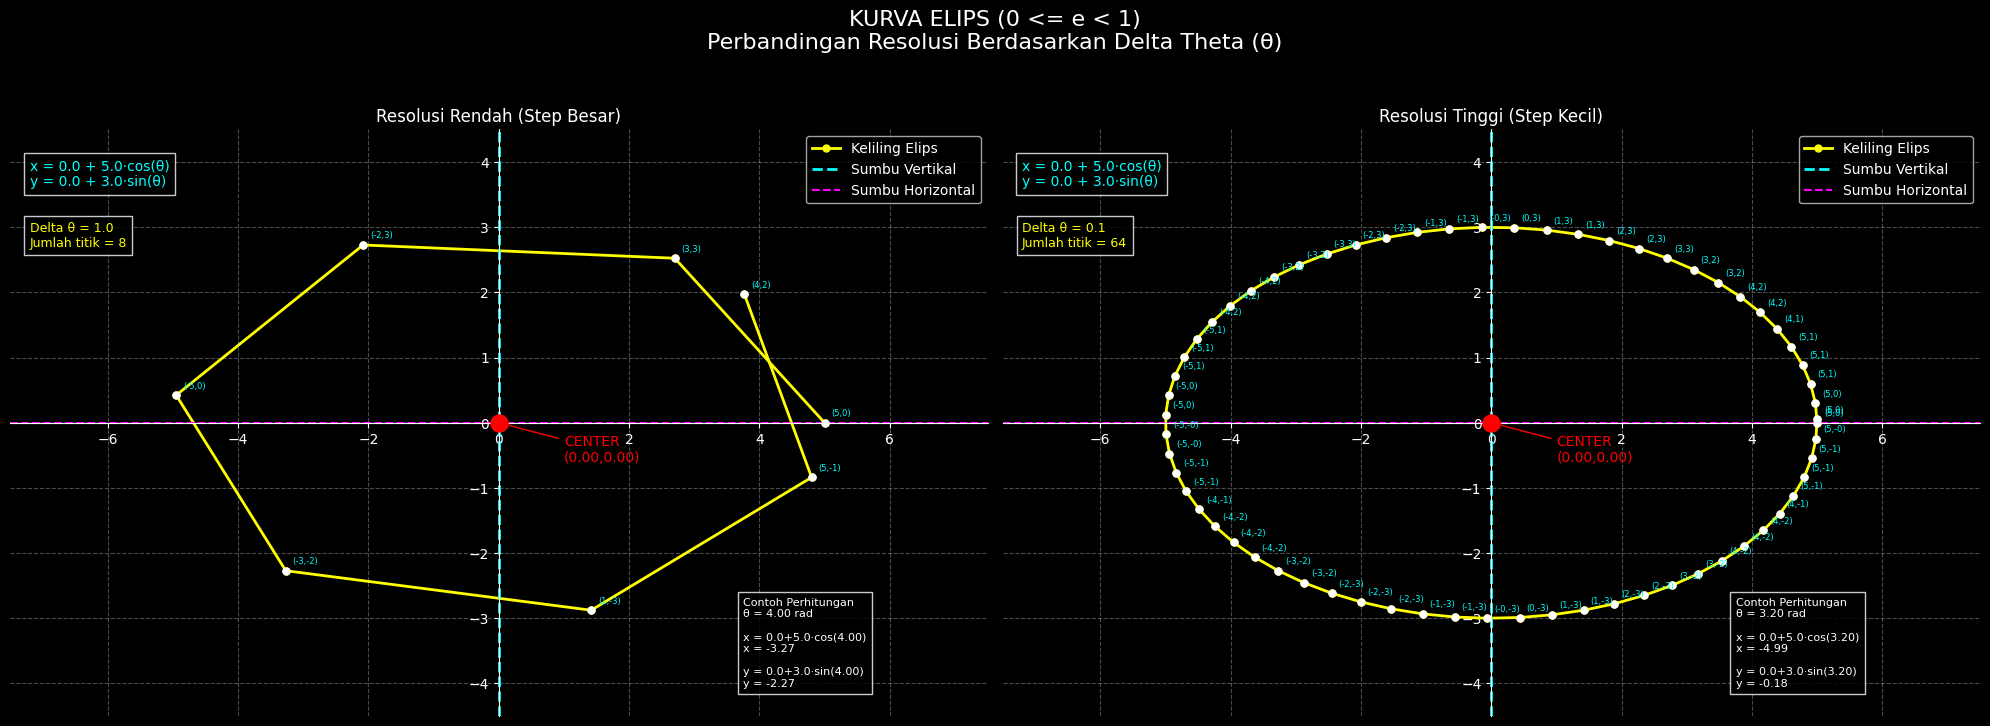

In [8]:
from matplotlib import style
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('dark_background')

def plot_elips():

    print("\n=== GENERATOR KURVA ELIPS ===\n")

    xc = float(input("Masukkan titik pusat X (xc): "))
    yc = float(input("Masukkan titik pusat Y (yc): "))
    a = float(input("Masukkan jari-jari horizontal (a): "))
    b = float(input("Masukkan jari-jari vertikal (b): "))

    step_low = float(input("Step besar (contoh 1.0): "))
    step_high = float(input("Step kecil (contoh 0.1): "))

    steps = [step_low, step_high]

    titles = [
        "Resolusi Rendah (Step Besar)",
        "Resolusi Tinggi (Step Kecil)"
    ]

    for col in range(2):
        step = steps[col]

        fig, ax = plt.subplots(figsize=(10, 8))
        fig.suptitle(
            "KURVA ELIPS (0 <= e < 1)\n"
            "Perbandingan Resolusi Berdasarkan Delta Theta (θ)",
            fontsize=14,
            color='white'
        )
        
        # Elips menggunakan rentang 0 sampai 2*pi
        theta = np.arange(0, 2 * np.pi + step, step)

        # Persamaan Parametrik Elips
        x = xc + a * np.cos(theta)
        y = yc + b * np.sin(theta)

        print("\n" + "=" * 100)

        if col == 0:
            print("RESOLUSI RENDAH")
        else:
            print("RESOLUSI TINGGI")

        print("=" * 100)

        print(f"Delta θ      = {step}")
        print(f"Jumlah titik = {len(theta)}")

        print("-" * 100)

        print(
            f"{'θ (rad)':<10}"
            f"{'Perhitungan X':<30}"
            f"{'X':<15}"
            f"{'Perhitungan Y':<25}"
            f"{'Y':<15}"
        )

        print("-" * 100)

        for i in range(len(theta)):
            calc_x = f"{xc}+{a}*cos({theta[i]:.2f})"
            calc_y = f"{yc}+{b}*sin({theta[i]:.2f})"

            print(
                f"{theta[i]:<10.2f}"
                f"{calc_x:<30}"
                f"{x[i]:<15.2f}"
                f"{calc_y:<25}"
                f"{y[i]:<15.2f}"
            )

        # ax = axes[col]

        # Plot Kurva Utama
        ax.plot(
            x,
            y,
            color='yellow',
            linewidth=2,
            marker='o',
            markersize=5,
            label='Keliling Elips'
        )
        ax.scatter(x, y, color='white', s=25, zorder=3)

        # Label Koordinat Titik
        limit_x_label = xc + 1.5 * a
        limit_y_label = yc + 1.5 * b
        
        for i in range(len(theta)):
            if abs(x[i]) <= limit_x_label and abs(y[i]) <= limit_y_label:
                ax.annotate(f'({x[i]:.0f},{y[i]:.0f})', (x[i], y[i]),
                            textcoords='offset points', xytext=(5, 5), fontsize=6, color='cyan')

        # Titik Pusat
        ax.scatter(
            xc,
            yc,
            color='red',
            s=150,
            zorder=10
        )

        ax.annotate(
            f'CENTER\n({xc:.2f},{yc:.2f})',
            xy=(xc, yc),
            xytext=(xc + a*0.2, yc - b*0.2), # Disesuaikan agar tidak bertabrakan dengan garis
            fontsize=10,
            color='red',
            arrowprops=dict(
                arrowstyle='->',
                color='red'
            )
        )

        # Garis Sumbu Pembantu
        ax.axvline(
            xc,
            color='cyan',
            linestyle='--',
            linewidth=2,
            label='Sumbu Vertikal'
        )

        ax.axhline(
            yc,
            color='magenta',
            linestyle='--',
            linewidth=1.5,
            label='Sumbu Horizontal'
        )

        # Kotak Rumus
        formula = (
            f"x = {xc} + {a}·cos(θ)\n"
            f"y = {yc} + {b}·sin(θ)"
        )

        ax.text(
            0.02,
            0.95,
            formula,
            transform=ax.transAxes,
            fontsize=10,
            color='cyan',
            verticalalignment='top',
            bbox=dict(
                facecolor='black',
                alpha=0.8
            )
        )

        # Kotak Info Delta
        info = (
            f"Delta θ = {step}\n"
            f"Jumlah titik = {len(theta)}"
        )

        ax.text(
            0.02,
            0.80,
            info,
            transform=ax.transAxes,
            fontsize=9,
            color='yellow',
            bbox=dict(
                facecolor='black',
                alpha=0.8
            )
        )

        # Kotak Contoh Perhitungan
        theta_example = theta[len(theta)//2]
        x_example = xc + a * np.cos(theta_example)
        y_example = yc + b * np.sin(theta_example)

        example = (
            f"Contoh Perhitungan\n"
            f"θ = {theta_example:.2f} rad\n\n"
            f"x = {xc}+{a}·cos({theta_example:.2f})\n"
            f"x = {x_example:.2f}\n\n"
            f"y = {yc}+{b}·sin({theta_example:.2f})\n"
            f"y = {y_example:.2f}"
        )

        ax.text(
            0.75,
            0.05,
            example,
            transform=ax.transAxes,
            fontsize=8,
            color='white',
            bbox=dict(
                facecolor='black',
                alpha=0.8
            )
        )

        # Pengaturan Frame dan Grid
        ax.spines['left'].set_position('zero')
        ax.spines['bottom'].set_position('zero')

        ax.spines['right'].set_color('none')
        ax.spines['top'].set_color('none')

        ax.tick_params(colors='white')

        ax.grid(
            True,
            linestyle='--',
            alpha=0.3
        )

        # Proporsi dan Limit sumbu
        ax.set_aspect('equal', adjustable='box') # Mencegah elips terlihat seperti lingkaran jika dilonggarkan
        ax.set_xlim(xc - 1.5*a, xc + 1.5*a)      # Margin 1.5x agar pas di layar
        ax.set_ylim(yc - 1.5*b, yc + 1.5*b)

        ax.set_title(
            titles[col],
            fontsize=12,
            color='white'
        )

        ax.legend(loc='upper right')

        plt.tight_layout()

    plt.show()

plot_elips()